# Palmer Penguins Modeling

Import the Palmer Penguins dataset and print out the first few rows.

Suppose we want to predict `bill_depth_mm` using the other variables in the dataset.

**Dummify** all variables that require this.

In [1]:
! pip install palmerpenguins

In [2]:
from palmerpenguins import load_penguins
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from plotnine import *

In [3]:
penguins = load_penguins()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [4]:
#drop NAs first
penguins = penguins.dropna()
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


In [5]:
#dummify required variables
penguins = pd.get_dummies(penguins)*1
penguins.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,species_Adelie,species_Chinstrap,species_Gentoo,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male
0,39.1,18.7,181.0,3750.0,2007,1,0,0,0,0,1,0,1
1,39.5,17.4,186.0,3800.0,2007,1,0,0,0,0,1,1,0
2,40.3,18.0,195.0,3250.0,2007,1,0,0,0,0,1,1,0
4,36.7,19.3,193.0,3450.0,2007,1,0,0,0,0,1,1,0
5,39.3,20.6,190.0,3650.0,2007,1,0,0,0,0,1,0,1


Let's use the other variables to predict `bill_depth_mm`. Prepare your data and fit the following models on a training dataset subset of the entire dataset:

* Four different models, each containing a different set of predictor variables

Create a plot like the right plot of Fig 1. in our `Model Validation` chapter with the training and test error plotted for each of your four models.

Which of your models was best?

In [6]:
#create training error table
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Model 1": ['bill_length_mm'],
    "Model 2": ['bill_length_mm', 'sex_female'],
    "Model 3": ['bill_length_mm', 'sex_female', 'flipper_length_mm'],
    "Model 4": ['bill_length_mm', 'sex_female', 'flipper_length_mm', 'body_mass_g']
}

rows = []
for name, Xcols in models.items():
    X_train = penguins[Xcols]
    y_train = penguins["bill_depth_mm"]
    model = LinearRegression().fit(X_train, y_train) #fit model
    y_train_ = model.predict(penguins[Xcols]) #make predictions
    penguins[f"{name}_predict"] = y_train_ #save prediction into main df
    train_mse = mean_squared_error(y_train, y_train_) #calculate mse for each model
    train_r2 = r2_score(y_train, y_train_) #calculate R^2 for each model
    rows.append({"Model": name, "Train RMSE": train_mse, "Train R2": train_r2}) #create rows for table below

train_error = pd.DataFrame(rows)
train_error

,Model,Train RMSE,Train R2
0,Model 1,3.664156,0.052270
1,Model 2,2.770816,0.283331
2,Model 3,1.438899,0.627830
3,Model 4,1.316219,0.659561


In [7]:
#partition data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(penguins.drop(['bill_depth_mm'], axis=1), penguins['bill_depth_mm'], test_size=0.25)

In [8]:
#create test error table
models = {
    "Model 1": ['bill_length_mm'],
    "Model 2": ['bill_length_mm', 'sex_female'],
    "Model 3": ['bill_length_mm', 'sex_female', 'flipper_length_mm'],
    "Model 4": ['bill_length_mm', 'sex_female', 'flipper_length_mm', 'body_mass_g']
}

rows = []
for name, Xcols in models.items():
    X = X_train[Xcols] #create training predictor df
    model = LinearRegression().fit(X, y_train) #fit model based on training data
    y_test_ = model.predict(X_test[Xcols]) #predict y values in test set based on X predictors in test data set
    X_test[f"{name}_predict"] = y_test_ #save predicted y to df
    test_mse = mean_squared_error(y_test, y_test_) #calculate MSE
    test_r2 = r2_score(y_test, y_test_) #calculate r^2
    rows.append({"Model": name, "Test RMSE": test_mse, "Test R2": test_r2})

test_error = pd.DataFrame(rows)
test_error

,Model,Test RMSE,Test R2
0,Model 1,3.591203,0.076844
1,Model 2,2.360345,0.393249
2,Model 3,1.297855,0.666373
3,Model 4,1.216352,0.687324


In [9]:
#plot training vs. test errors
penguins_error = train_error.merge(test_error, on="Model")
penguins_error

,Model,Train RMSE,Train R2,Test RMSE,Test R2
0,Model 1,3.664156,0.052270,3.591203,0.076844
1,Model 2,2.770816,0.283331,2.360345,0.393249
2,Model 3,1.438899,0.627830,1.297855,0.666373
3,Model 4,1.316219,0.659561,1.216352,0.687324


In [10]:
penguins_error_long = penguins_error[["Model", "Train RMSE", "Test RMSE"]].melt(id_vars=["Model"], value_name = "RMSE", var_name = "type")
penguins_error_long

,Model,type,RMSE
0,Model 1,Train RMSE,3.664156
1,Model 2,Train RMSE,2.770816
2,Model 3,Train RMSE,1.438899
3,Model 4,Train RMSE,1.316219
4,Model 1,Test RMSE,3.591203
5,Model 2,Test RMSE,2.360345
6,Model 3,Test RMSE,1.297855
7,Model 4,Test RMSE,1.216352


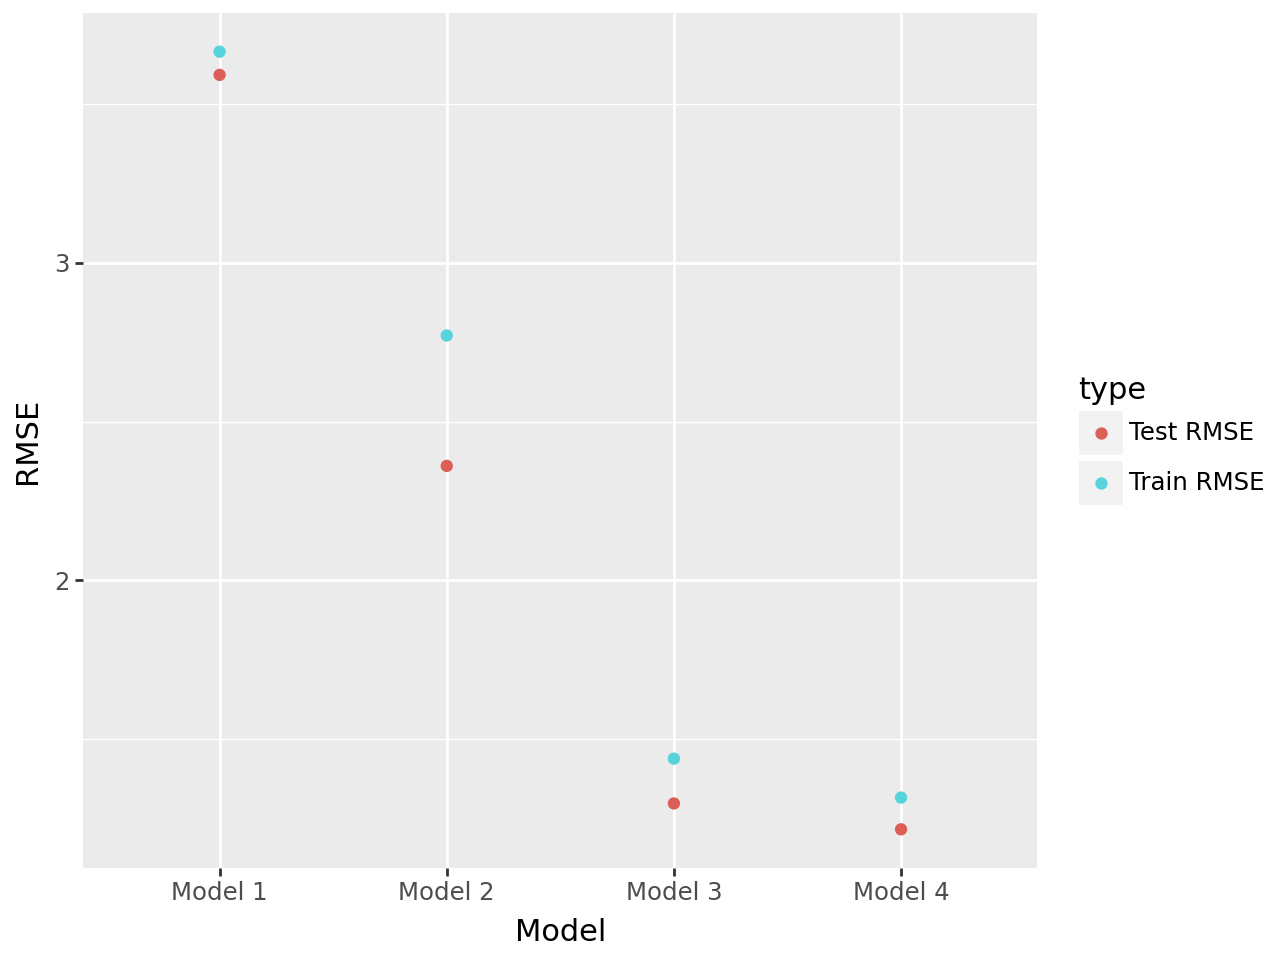

In [11]:
(ggplot(penguins_error_long,
        aes(x = "Model",
            y = "RMSE",
            color = "type")) +
 geom_point())

Given the plot above, it appears that as the models become more complex, root mean square error decreases for both the test and training sets. Model 4 predicting bill depth with bill length, sex, flipper length, and body mass appears to perform the best in terms of predictive power due to having the smallest root mean square error.